# NLP Sentiment Analysis Comparison

TF-IDF vs One-Hot Encoding

Models:
- TF-IDF + Naive Bayes
- TF-IDF + Logistic Regression
- TF-IDF + SVM
- One-Hot + Logistic Regression
- One-Hot + Random Forest
- One-Hot + SVM

In [30]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


In [31]:
# LOAD DATASET
import io

# Baca file dan bersihkan tanda kutip ekstra yang membungkus seluruh baris
with open('../data/raw/sentiment-analysis.csv', 'r', encoding='utf-8') as f:
    lines = [line.strip().strip('"') for line in f.readlines()]

df = pd.read_csv(io.StringIO('\n'.join(lines)))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Gunakan kolom 'Text'
X_text = df['Text'].fillna('').apply(clean_text)

# Gunakan kolom ' Sentiment' dan ubah Positive -> 1, Negative -> 0
y = df[' Sentiment'].str.strip().map({'Positive': 1, 'Negative': 0}).fillna(0).astype(int)


In [32]:

# TRAIN TEST SPLIT

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [33]:

# TF-IDF

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=1,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(np.array(X_train_text))
X_test_tfidf = tfidf.transform(np.array(X_test_text))

print('TF-IDF Features:', len(tfidf.get_feature_names_out()))


TF-IDF Features: 556


In [34]:

# ONE HOT ENCODING

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

X_train_ohe = ohe.fit_transform(np.array(X_train_text).reshape(-1, 1))
X_test_ohe = ohe.transform(np.array(X_test_text).reshape(-1, 1))

print('One Hot Categories:', len(ohe.get_feature_names_out()))


One Hot Categories: 55


In [35]:
results = []

def save_result(name,y_true,pred,prob):
    results.append([
        name,
        accuracy_score(y_true,pred),
        f1_score(y_true,pred,average='weighted'),
        roc_auc_score(y_true,prob),
        sum(pred==0),
        sum(pred==1)
    ])


In [36]:

# TF-IDF + NAIVE BAYES

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf,y_train)

pred = nb_model.predict(X_test_tfidf)
prob = nb_model.predict_proba(X_test_tfidf)[:,1]

save_result('TFIDF + Naive Bayes',y_test,pred,prob)


In [37]:

# TF-IDF + LOGISTIC REGRESSION

lr_model = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_tfidf,y_train)

pred = lr_model.predict(X_test_tfidf)
prob = lr_model.predict_proba(X_test_tfidf)[:,1]

save_result('TFIDF + Logistic Regression',y_test,pred,prob)


In [38]:

# TF-IDF + SVM

base_svm = LinearSVC(
    C=0.5,
    class_weight='balanced',
    random_state=42,
    max_iter=2000
)

svm_model = CalibratedClassifierCV(base_svm,cv=3)
svm_model.fit(X_train_tfidf,y_train)

pred = svm_model.predict(X_test_tfidf)
prob = svm_model.predict_proba(X_test_tfidf)[:,1]

save_result('TFIDF + SVM',y_test,pred,prob)


In [39]:

# ONE HOT + LOGISTIC REGRESSION

lr_ohe = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

lr_ohe.fit(X_train_ohe,y_train)

pred = lr_ohe.predict(X_test_ohe)
prob = lr_ohe.predict_proba(X_test_ohe)[:,1]

save_result('OneHot + Logistic Regression',y_test,pred,prob)


In [40]:

# ONE HOT + RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ohe,y_train)

pred = rf.predict(X_test_ohe)
prob = rf.predict_proba(X_test_ohe)[:,1]

save_result('OneHot + Random Forest',y_test,pred,prob)


In [41]:

# ONE HOT + SVM

base_svm_ohe = LinearSVC(
    C=0.5,
    class_weight='balanced',
    random_state=42,
    max_iter=2000
)

svm_ohe = CalibratedClassifierCV(base_svm_ohe,cv=3)

svm_ohe.fit(X_train_ohe,y_train)

pred = svm_ohe.predict(X_test_ohe)
prob = svm_ohe.predict_proba(X_test_ohe)[:,1]

save_result('OneHot + SVM',y_test,pred,prob)


In [42]:
comparison = pd.DataFrame(
    results,
    columns=['Model','Accuracy','F1','ROC_AUC', 'Prediksi_Negatif', 'Prediksi_Positif']
)

comparison = comparison.sort_values(
    'Accuracy',
    ascending=False
)

comparison


,Model,Accuracy,F1,ROC_AUC,Prediksi_Negatif,Prediksi_Positif
0,TFIDF + Naive Bayes,0.896552,0.894239,0.894231,10,19
1,TFIDF + Logistic Regression,0.896552,0.894239,0.894231,10,19
2,TFIDF + SVM,0.896552,0.894239,0.908654,10,19
3,OneHot + Logistic Regression,0.620690,0.530126,0.682692,2,27
4,OneHot + Random Forest,0.620690,0.530126,0.682692,2,27
5,OneHot + SVM,0.620690,0.530126,0.682692,2,27


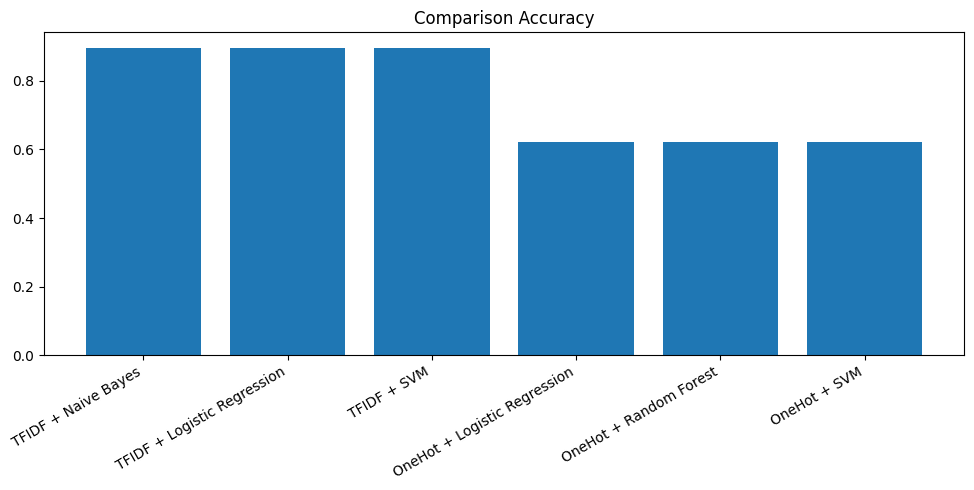

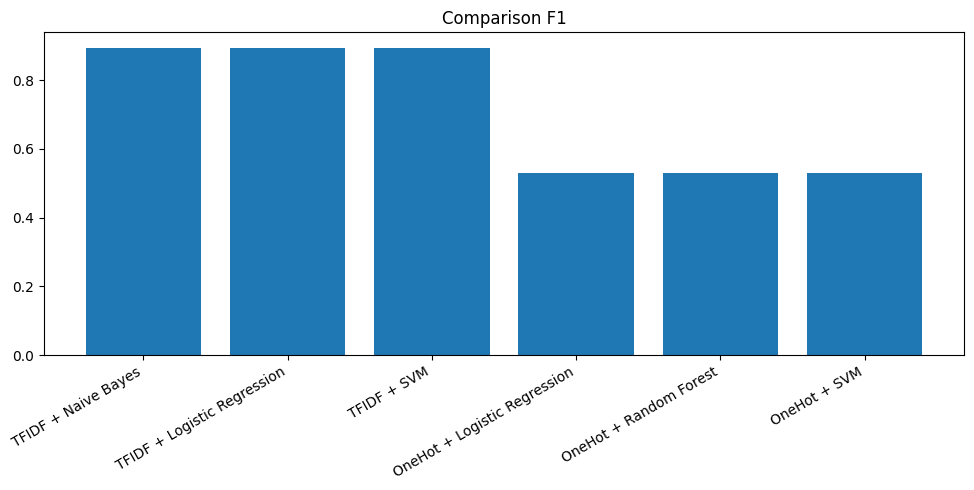

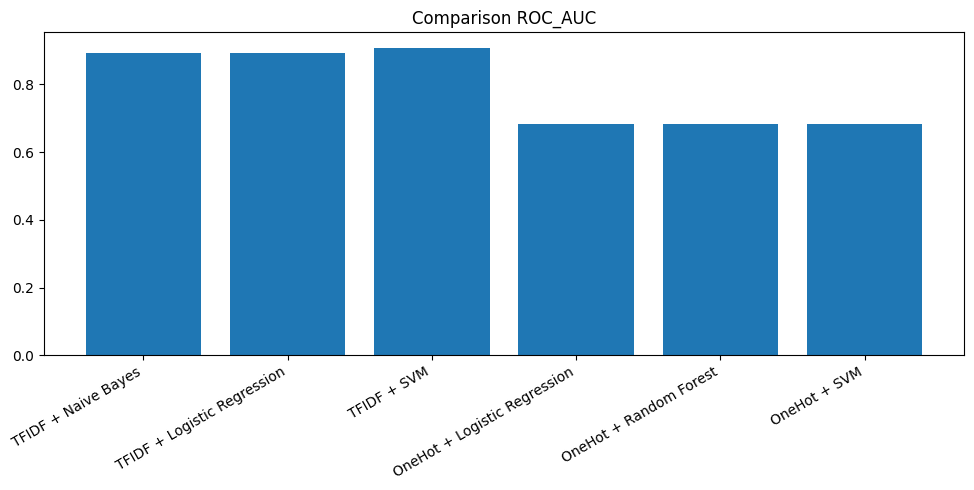

In [43]:

for metric in ['Accuracy','F1','ROC_AUC']:

    plt.figure(figsize=(10,5))

    plt.bar(comparison['Model'],comparison[metric])

    plt.title(f'Comparison {metric}')

    plt.xticks(rotation=30,ha='right')

    plt.tight_layout()

    plt.show()


C:\Users\mp2pf\AppData\Local\Temp\ipykernel_19920\3620340622.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


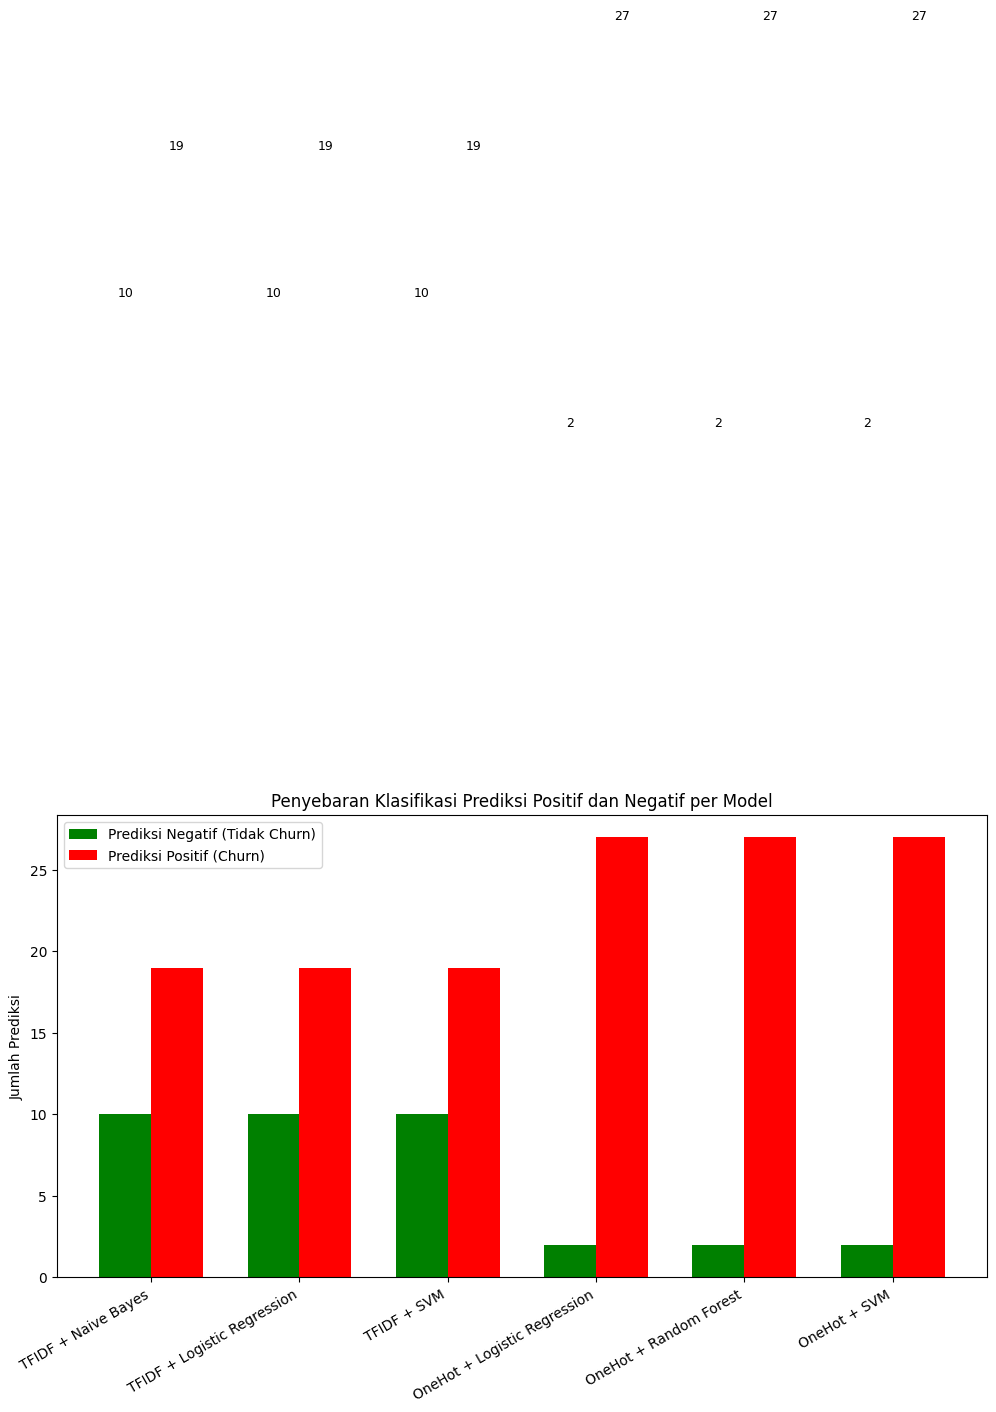

In [44]:
# Plot Distribusi Klasifikasi Positif vs Negatif
plt.figure(figsize=(12, 6))

x = np.arange(len(comparison['Model']))
width = 0.35

plt.bar(x - width/2, comparison['Prediksi_Negatif'], width, label='Prediksi Negatif (Tidak Churn)', color='green')
plt.bar(x + width/2, comparison['Prediksi_Positif'], width, label='Prediksi Positif (Churn)', color='red')

# Tampilkan angka di atas bar
for i, v in enumerate(comparison['Prediksi_Negatif']):
    plt.text(i - width/2, v + 50, str(v), ha='center', va='bottom', fontsize=9)
for i, v in enumerate(comparison['Prediksi_Positif']):
    plt.text(i + width/2, v + 50, str(v), ha='center', va='bottom', fontsize=9)

plt.title('Penyebaran Klasifikasi Prediksi Positif dan Negatif per Model')
plt.xticks(x, comparison['Model'], rotation=30, ha='right')
plt.ylabel('Jumlah Prediksi')
plt.legend()
plt.tight_layout()
plt.show()
